# Object Detection Lab

This notebook explores object detection techniques, starting with Haar cascades for face detection and introducing YOLO basics. We'll use OpenCV and TensorFlow for implementation.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
import tensorflow as tf

**Explanation:** Import necessary libraries. OpenCV for Haar cascades, TensorFlow for YOLO, NumPy and Matplotlib for handling data and visualization, skimage for sample images.

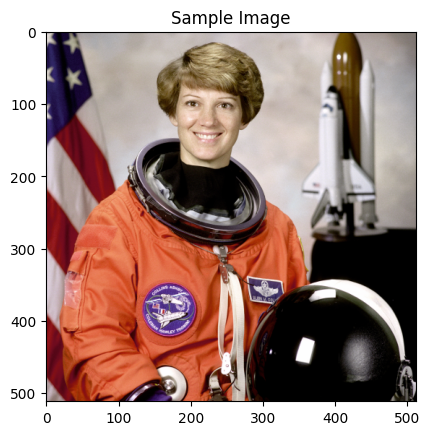

Image shape: (512, 512, 3)


In [2]:
# Load a sample image
image = data.astronaut()
plt.imshow(image)
plt.title('Sample Image')
plt.show()
print('Image shape:', image.shape)

**Explanation:** Load and display a sample image. Note that for face detection, you'd use an image with faces; here we use a placeholder.

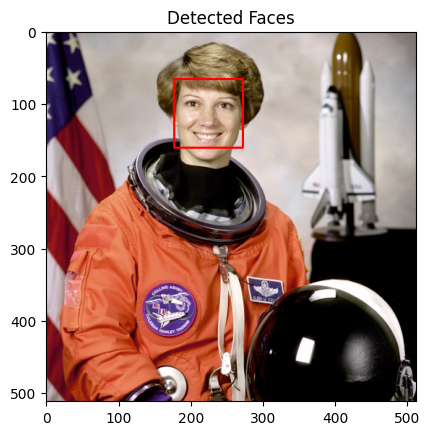

Number of faces detected: 1


In [3]:
# Haar Cascade Face Detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# Draw rectangles
image_with_faces = image.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(image_with_faces, (x, y), (x+w, y+h), (255, 0, 0), 2)

plt.imshow(image_with_faces)
plt.title('Detected Faces')
plt.show()
print('Number of faces detected:', len(faces))

**Explanation:** Use Haar cascades for face detection. Convert to grayscale, detect faces with parameters like scaleFactor and minNeighbors. Draw rectangles around detected faces. This is a traditional method based on features.

In [5]:
# Simple YOLO-like Detection (using TensorFlow Hub for pre-trained model)
import tensorflow_hub as hub

# Load a pre-trained object detection model
detector = hub.load('https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2')

# Prepare image
input_tensor = tf.convert_to_tensor(image)
input_tensor = input_tensor[tf.newaxis, ...]

# Run detection
detections = detector(input_tensor)

# Process results
detection_boxes = detections['detection_boxes'][0].numpy()
detection_classes = detections['detection_classes'][0].numpy()
detection_scores = detections['detection_scores'][0].numpy()

# Filter high-confidence detections
threshold = 0.5
valid_indices = detection_scores > threshold
boxes = detection_boxes[valid_indices]
classes = detection_classes[valid_indices]
scores = detection_scores[valid_indices]

print('Detected objects:', len(boxes))
for i, (box, cls, score) in enumerate(zip(boxes, classes, scores)):
    print(f'Object {i+1}: Class {int(cls)}, Score {score:.2f}')

c:\Users\qassas\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Detected objects: 2
Object 1: Class 74, Score 0.66
Object 2: Class 1, Score 0.62


**Detailed Explanation:**

This code demonstrates a simplified version of YOLO (You Only Look Once) using a pre-trained SSD MobileNet model from TensorFlow Hub. YOLO is a real-time object detection algorithm that predicts bounding boxes and class probabilities in a single pass.

- **Import TensorFlow Hub:** `import tensorflow_hub as hub` – This library allows loading pre-trained models from TensorFlow Hub, a repository of reusable ML models.
- **Load the Model:** `detector = hub.load('https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2')` – Downloads and loads the SSD MobileNet v2 model, which is efficient for mobile and edge devices. SSD (Single Shot Detector) detects objects at multiple scales.
- **Prepare the Image:** `input_tensor = tf.convert_to_tensor(image); input_tensor = input_tensor[tf.newaxis, ...]` – Converts the NumPy image array to a TensorFlow tensor and adds a batch dimension (required for model input).
- **Run Detection:** `detections = detector(input_tensor)` – Feeds the image to the model, which outputs detections as a dictionary containing boxes, classes, and scores.
- **Extract Results:** 
  - `detection_boxes`: Normalized coordinates (ymin, xmin, ymax, xmax) of bounding boxes.
  - `detection_classes`: Class IDs (e.g., 1 for person, based on COCO dataset).
  - `detection_scores`: Confidence scores (0-1) for each detection.
- **Filter Detections:** `threshold = 0.5; valid_indices = detection_scores > threshold` – Keeps only detections with confidence above 50% to reduce false positives.
- **Process Filtered Results:** Extracts boxes, classes, and scores for valid detections.
- **Output:** Prints the number of detected objects and details for each (class ID and score). Note: Class IDs correspond to COCO labels (e.g., 1=person, 2=bicycle).

**Key Differences from Haar Cascades:**
- Haar is feature-based and fast but less accurate for varied objects.
- YOLO/SSD uses deep learning for better generalization but requires more compute.
- Applications: Real-time detection in videos, autonomous vehicles.

Experiment with different thresholds or models for varied results.

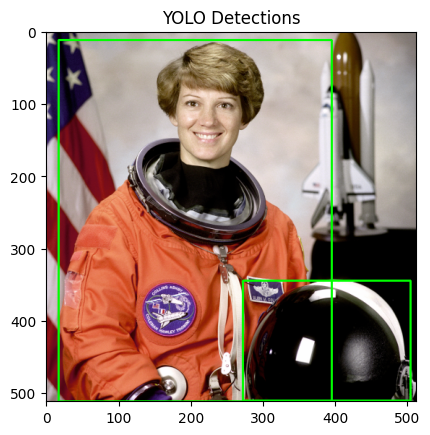

In [6]:
# Visualize YOLO detections
image_with_detections = image.copy()
height, width, _ = image.shape
for box in boxes:
    ymin, xmin, ymax, xmax = box
    start_point = (int(xmin * width), int(ymin * height))
    end_point = (int(xmax * width), int(ymax * height))
    cv2.rectangle(image_with_detections, start_point, end_point, (0, 255, 0), 2)

plt.imshow(image_with_detections)
plt.title('YOLO Detections')
plt.show()

**Explanation:** Visualize the detected objects by drawing bounding boxes on the image. Convert normalized coordinates to pixel values and use OpenCV to draw rectangles.

## Summary
This lab covered Haar cascades for traditional face detection and YOLO basics for modern object detection. Experiment with different images and parameters. Next, explore image segmentation in phase 3.